# Analisi della social network tra istituti di ricerca e università.
L'obiettivo di questa analisi è quella di individuare se, all'interno della comunità scientifica, esistano
dei gruppi naturali (comunità) tra i diversi istituti di ricerca nel campo della Energia.

In [1]:
from importlib import reload
from datetime import datetime
from pathlib import Path
from tqdm.notebook import tqdm
from importlib import reload  # Python 3.4+
import utils.graphing as graphing
import utils.metrics as metrics
import networkx as nx
import os
from time import sleep
import pandas as pd
import utils.preproc as preproc
import warnings
import math


CITATIONS_DIRECTED_GRAPH = "./data/cit-HepTh.txt"
CITATIONS_ABSTRACTS_DIR = "./data/cit-HepTh-abstracts"

ROR_DATA = "./data/ror-data.csv"
UNIVERSITIES_DATA = "./data/all_universities.csv"

warnings.filterwarnings("ignore")

## nuova sessione
Questa linea genera la session_id.
Se la sovrascrivi si intende che hai fatto cambiamenti al dataset perciò il resto del codice non farà più affidamento alla sessione precedente e quindi alcuni file
vanno rigenerati

In [ ]:
s = datetime.now().strftime("%y%m%d%H%M")
session_id = f"{s}"  # NUOVA SESSIONE
SESSION_PATH = f"data/sessions/{session_id}"
os.makedirs(SESSION_PATH, exist_ok=True)

## caricamento sessione

In [3]:
session_id = "2511212247"  # RICARICA UNA SESSIONE
SESSION_PATH = f"data/sessions/{session_id}"

In [4]:
citations_uni = pd.read_csv(f"{SESSION_PATH}/citations-uni.csv")
citations_country = pd.read_csv(f"{SESSION_PATH}/citations-country.csv")
papers = pd.read_csv(f"{SESSION_PATH}/papers.csv")

# Preprocessamento
eseguiamo le operazioni preliminari di caricamento dei dati

citations contiene il grafo diretto con colonne target e source

In [ ]:
records = []

for abp in tqdm(Path(CITATIONS_ABSTRACTS_DIR).rglob("*")):
    if abp.is_file():
        with open(abp, "r", encoding="utf-8", errors="ignore") as f:
            abs = f.read()

        data = {"id": abp.stem}
        fields = preproc.extract_fields(abs)
        # preproc è una classe statica definita in utils.py

        if isinstance(fields, dict):
            data.update(fields)
            records.append(data)

papers = pd.DataFrame(records)
del records

Mapping dei paper alle rispettive università

In [ ]:
ror = pd.read_csv(ROR_DATA)
ror["clean_url"] = (
    ror["links"].str.replace(r"^https?://", "", regex=True).str.split("/").str[0]
)
ror["tld2"] = ror["clean_url"].str.extract(r"([a-zA-Z0-9-]+\.[a-zA-Z0-9-]+)$")

universities = pd.read_csv(UNIVERSITIES_DATA)

domain_mapping = {
    str(row.id): preproc.extract_domain(row.email, ror, universities)
    for row in tqdm(papers.itertuples())
}

In [ ]:
# leggi il file come edge-list: ignora righe che iniziano con '#' e usa whitespace come separatore

cit_hepth = pd.read_csv(
    CITATIONS_DIRECTED_GRAPH, comment="#", sep="\\s+", header=None, engine="python"
)

# Prendiamo le prime due colonne come source/target
citations = cit_hepth.iloc[:, :2].copy()
citations.columns = ["source", "target"]
citations["source"] = pd.to_numeric(citations["source"])
citations["target"] = pd.to_numeric(citations["target"])

del cit_hepth  # non ci serve più

citations_uni = citations.copy()
citations_country = citations.copy()


def safe_get_name(x):
    v = domain_mapping.get(x)
    if isinstance(v, dict):
        return v.get("name")
    return None


def safe_get_country(x):
    v = domain_mapping.get(x)
    if isinstance(v, dict):
        return v.get("country")
    return None


citations_uni["source"] = citations["source"].astype(str).map(safe_get_name)
citations_uni["target"] = citations["target"].astype(str).map(safe_get_name)

citations_country["source"] = citations["source"].astype(str).map(safe_get_country)
citations_country["target"] = citations["target"].astype(str).map(safe_get_country)

In [ ]:
citations_uni.dropna().sample(n=3)

In [ ]:
citations_country.dropna().sample(n=3)

## salvataggio

In [ ]:
citations_uni.to_csv(f"{SESSION_PATH}/citations-uni.csv", index=False)
citations_country.to_csv(f"{SESSION_PATH}/citations-country.csv", index=False)

In [ ]:
papers.to_csv(f"{SESSION_PATH}/papers.csv", index=False)

# EDA

In [7]:
unique = len(
    pd.unique(citations_country[["source", "target"]].dropna().values.ravel("K"))
)
self_loops = len(
    citations_country[
        citations_country["source"] == citations_country["target"]
    ].dropna()
)
edges = len(citations_country.dropna())
print(f"Abbiamo {unique} stati")
print(f"        {edges} archi")
print(f"        {self_loops} self loops")

Abbiamo 63 stati
        153881 archi
        57976 self loops


In [5]:
unique = len(pd.unique(citations_uni[["source", "target"]].dropna().values.ravel("K")))
self_loops = len(
    citations_uni[citations_uni["source"] == citations_uni["target"]].dropna()
)
edges = len(citations_uni.dropna())
print(f"Abbiamo {unique} universita e centri di ricerca")
print(f"        {edges} archi")
print(f"        {self_loops} self loops")

Abbiamo 560 universita e centri di ricerca
        153881 archi
        21490 self loops


# Grafi

## Grafi con NaN - no metriche

In [ ]:
# per testing e sviluppo delle librerie, rilanciare questo blocco ogni volta che viene
# aggiornata una libreria

# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
graphing = reload(graphing)

### Circular Layout

In [ ]:
name = "circular-wpg"
pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
wpg = graphing.edge_collapse(pg, nx.DiGraph)
lay = graphing.GLAYOUTS.circular
pos = lay(wpg)
data = graphing.gen_graph_data(wpg, pos)
graphing.plot_graph(data, save_path=f"{SESSION_PATH}/{name}")

### ARF Layout

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
from importlib import reload  # Python 3.4+

graphing = reload(graphing)
name = "graph-arf-wpg"
pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
wpg = graphing.edge_collapse(pg, nx.DiGraph)
lay = graphing.GLAYOUTS.arf
pos = lay(wpg)
data = graphing.gen_graph_data(wpg, pos)
graphing.plot_graph(data, save_path=f"{SESSION_PATH}/{name}")

### Kamada Kawai

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
from importlib import reload  # Python 3.4+

graphing = reload(graphing)
name = "kamada-wpg"
pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
wpg = graphing.edge_collapse(pg, nx.DiGraph)
lay = graphing.GLAYOUTS.kamada
pos = lay(wpg, weight="w")
data = graphing.gen_graph_data(wpg, pos)
graphing.plot_graph(data, save_path=f"{SESSION_PATH}/{name}")

### Spring

#### Base (Auto)

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
from importlib import reload  # Python 3.4+

graphing = reload(graphing)
name = "spring-base-wpg"
pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
wpg = graphing.edge_collapse(pg, nx.DiGraph)
lay = graphing.GLAYOUTS.spring
pos = lay(wpg, weight="w")
data = graphing.gen_graph_data(wpg, pos)
graphing.plot_graph(data, save_path=f"{SESSION_PATH}/{name}")

#### Force

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
from importlib import reload  # Python 3.4+

graphing = reload(graphing)
name = "spring-force-wpg"
pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
wpg = graphing.edge_collapse(pg, nx.DiGraph)
lay = graphing.GLAYOUTS.spring
pos = lay(wpg, weight="w", method="force")
data = graphing.gen_graph_data(wpg, pos)
graphing.plot_graph(data, save_path=f"{SESSION_PATH}/{name}")

#### Energy

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
from importlib import reload  # Python 3.4+

graphing = reload(graphing)
name = "spring-energy-wpg"
pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
wpg = graphing.edge_collapse(pg, nx.DiGraph)
lay = graphing.GLAYOUTS.spring
pos = lay(wpg, weight="w", method="energy")
data = graphing.gen_graph_data(wpg, pos)
graphing.plot_graph(data, save_path=f"{SESSION_PATH}/{name}", show_labels=False)

Visualizzazione del grafo

## Grafi e metriche con NaN 
Prima di continuare, bisogna calcolare le metriche

In [36]:
gm = metrics.GraphMetrics(pg, SESSION_PATH)
gm.calc_metrics()

In [40]:
degree_df = pd.DataFrame(gm.degree_cent.items(), columns=['Node', 'DegreeCentrality'])

print(degree_df.sort_values(by='DegreeCentrality', ascending=False).head(11))
print(degree_df.sort_values(by='DegreeCentrality', ascending=True).head(10))

                                                 Node  DegreeCentrality
0                                                 NaN          1.495667
2          European Organization for Nuclear Research          0.916811
26                       London South Bank University          0.870017
35  Istituto Nazionale di Fisica Nucleare, Sezione...          0.823224
17                               Princeton University          0.814558
3                        Institute for Advanced Study          0.776430
32                            University of Cambridge          0.774697
52              Massachusetts Institute of Technology          0.745234
9                                  Harvard University          0.720971
6                                  Rutgers University          0.717504
8             University of California, Santa Barbara          0.715771
                                          Node  DegreeCentrality
576               Technical University of Iasi          0.001733
530   

In [41]:
closeness_df = pd.DataFrame(gm.closeness_cent.items(), columns=['Node', 'ClosenessCentrality'])

print(closeness_df.sort_values(by='ClosenessCentrality', ascending=False).head(11))
print(closeness_df.sort_values(by='ClosenessCentrality', ascending=True).head(10))

                                                 Node  ClosenessCentrality
0                                                 NaN             0.710064
2          European Organization for Nuclear Research             0.650269
17                               Princeton University             0.644334
6                                  Rutgers University             0.637683
3                        Institute for Advanced Study             0.633596
26                       London South Bank University             0.623996
8             University of California, Santa Barbara             0.617756
35  Istituto Nazionale di Fisica Nucleare, Sezione...             0.607131
32                            University of Cambridge             0.605643
52              Massachusetts Institute of Technology             0.600492
9                                  Harvard University             0.591862
                                                  Node  ClosenessCentrality
577                Calif

In [42]:
betweenness_df = pd.DataFrame(gm.betweenness_cent.items(), columns=['Node', 'BetweennessCentrality'])

print(betweenness_df.sort_values(by='BetweennessCentrality', ascending=False).head(11))
print(betweenness_df.sort_values(by='BetweennessCentrality', ascending=True).head(10))

                                                 Node  BetweennessCentrality
0                                                 NaN               0.329936
26                       London South Bank University               0.042151
2          European Organization for Nuclear Research               0.040807
35  Istituto Nazionale di Fisica Nucleare, Sezione...               0.034614
17                               Princeton University               0.028821
52              Massachusetts Institute of Technology               0.025037
32                            University of Cambridge               0.021299
3                        Institute for Advanced Study               0.020217
56                                   Kyoto University               0.016466
8             University of California, Santa Barbara               0.016277
9                                  Harvard University               0.015960
                                          Node  BetweennessCentrality
577   

In [43]:
eigenvector_df = pd.DataFrame(gm.eigenvector_cent.items(), columns=['Node', 'EigenvectorCentrality'])

print(eigenvector_df.sort_values(by='EigenvectorCentrality', ascending=False).head(11))
print(eigenvector_df.sort_values(by='EigenvectorCentrality', ascending=True).head(10))

                                                 Node  EigenvectorCentrality
0                                                 NaN               0.150539
2          European Organization for Nuclear Research               0.145859
17                               Princeton University               0.144902
6                                  Rutgers University               0.144293
3                        Institute for Advanced Study               0.143135
8             University of California, Santa Barbara               0.140734
26                       London South Bank University               0.140123
32                            University of Cambridge               0.136996
9                                  Harvard University               0.136015
35  Istituto Nazionale di Fisica Nucleare, Sezione...               0.134643
12                                Stanford University               0.133646
                                                  Node  EigenvectorCentralit

In [ ]:
gm = metrics.GraphMetrics(pg, SESSION_PATH)
gm.calc_metrics()

In [ ]:
degree_df = pd.DataFrame(gm.degree_cent.items(), columns=['Node', 'DegreeCentrality'])

print(degree_df.sort_values(by='DegreeCentrality', ascending=False).head(11))
print(degree_df.sort_values(by='DegreeCentrality', ascending=True).head(10))

In [ ]:
closeness_df = pd.DataFrame(gm.closeness_cent.items(), columns=['Node', 'ClosenessCentrality'])

print(closeness_df.sort_values(by='ClosenessCentrality', ascending=False).head(11))
print(closeness_df.sort_values(by='ClosenessCentrality', ascending=True).head(10))

In [ ]:
betweenness_df = pd.DataFrame(gm.betweenness_cent.items(), columns=['Node', 'BetweennessCentrality'])

print(betweenness_df.sort_values(by='BetweennessCentrality', ascending=False).head(11))
print(betweenness_df.sort_values(by='BetweennessCentrality', ascending=True).head(10))

In [ ]:
eigenvector_df = pd.DataFrame(gm.eigenvector_cent.items(), columns=['Node', 'EigenvectorCentrality'])

print(eigenvector_df.sort_values(by='EigenvectorCentrality', ascending=False).head(11))
print(eigenvector_df.sort_values(by='EigenvectorCentrality', ascending=True).head(10))

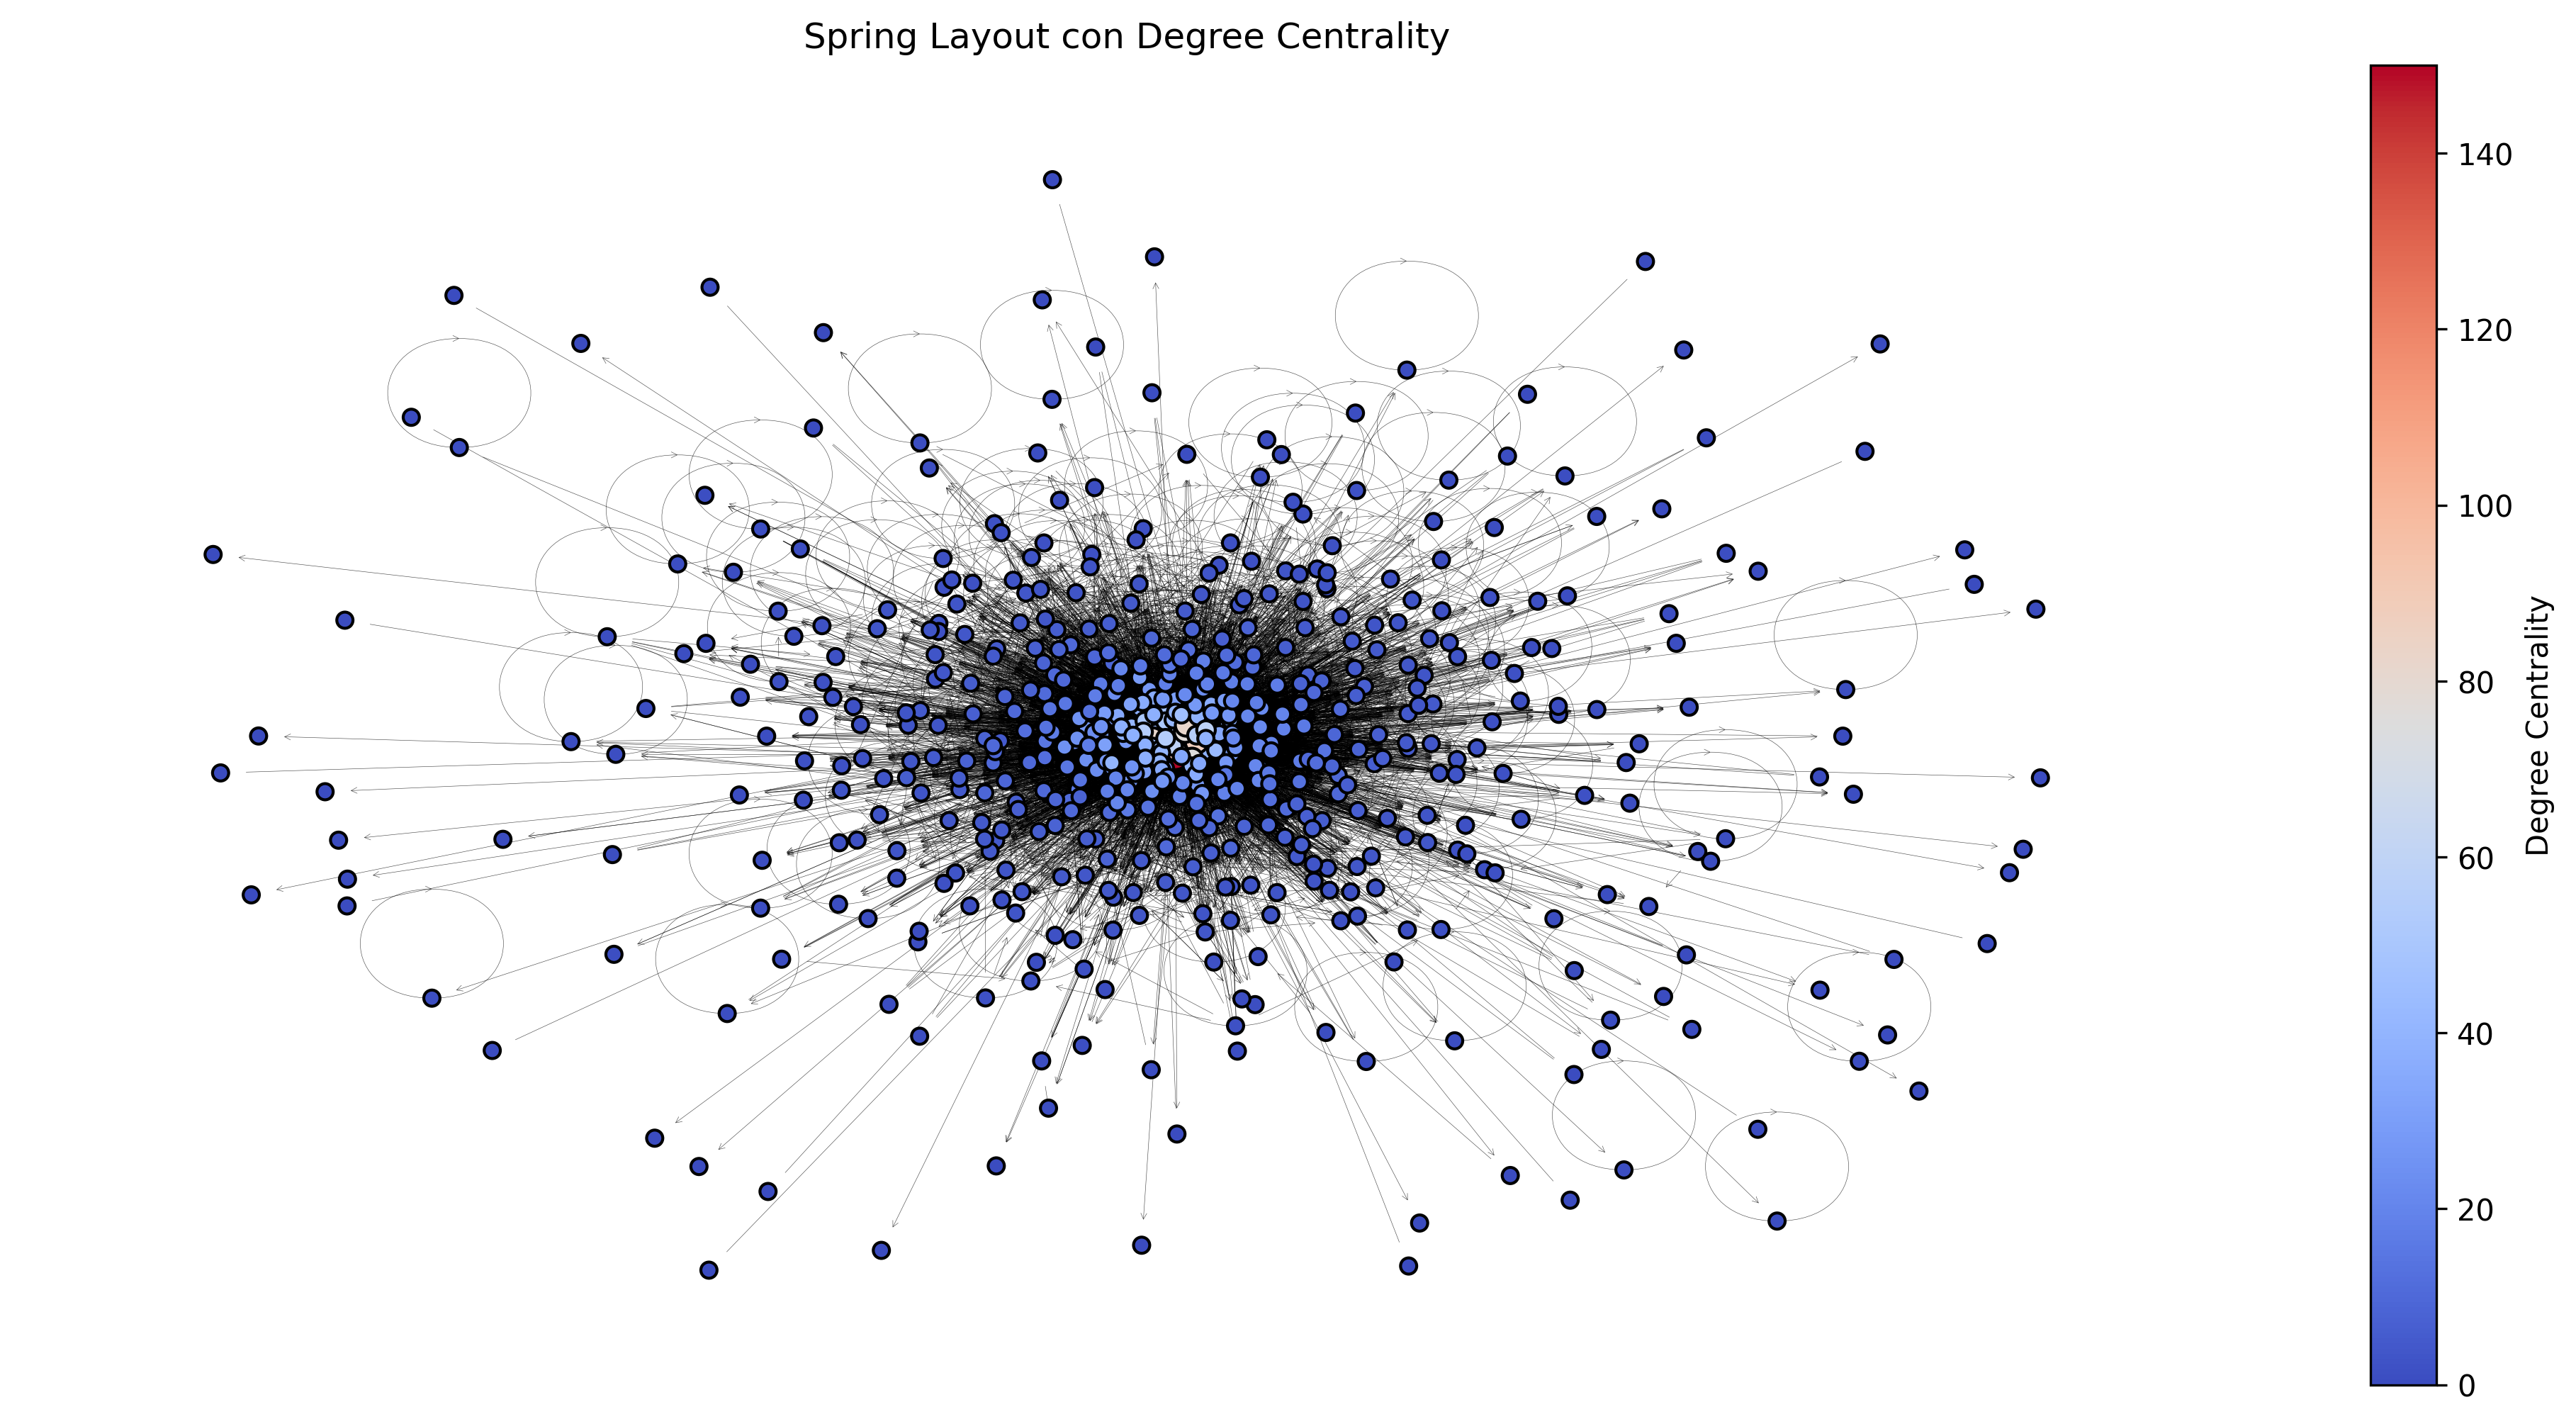

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
from importlib import reload  # Python 3.4+
metrics = reload(metrics)
graphing = reload(graphing)

name = "spring-DEGREE"
label = "Degree Centrality"
title = "Spring Layout con Degree Centrality"

pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
lay = graphing.GLAYOUTS.spring 
pos = lay(pg, weight="w", method="energy")

gm = metrics.GraphMetrics(pg, SESSION_PATH)
gm.calc_metrics()
data = graphing.gen_graph_data(pg, pos, gm.degree_cent)
data["node_colors"] = [round(i*100) for i in gm.degree_cent.values()]
graphing.plot_graph(data, label=label, title=title, figsize=graphing.FigSize.XXXL16_9, save_path=f"{SESSION_PATH}/{name}", show_labels=False)

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
from importlib import reload  # Python 3.4+
metrics = reload(metrics)
graphing = reload(graphing)

name = "spring-CLOSENESS"
label = "Closeness Centrality"
title = "Spring Layout con Closeness Centrality"

pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
lay = graphing.GLAYOUTS.spring
pos = lay(pg, weight="w", method="energy")

gm = metrics.GraphMetrics(pg, SESSION_PATH)
gm.calc_metrics()
data = graphing.gen_graph_data(pg, pos, gm.closeness_cent)
data["node_colors"] = [round(i*100) for i in gm.closeness_cent.values()]
graphing.plot_graph(data, label=label, title=title,figsize=graphing.FigSize.XXXL16_9, save_path=f"{SESSION_PATH}/{name}", show_labels=False)

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
from importlib import reload  # Python 3.4+
metrics = reload(metrics)
graphing = reload(graphing)

name = "spring-BETWEENNESS"
label = "Betweenness Centrality"
title = "Spring Layout con Betweenness Centrality"

pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
lay = graphing.GLAYOUTS.spring
pos = lay(pg, weight="w", method="energy")

gm = metrics.GraphMetrics(pg, SESSION_PATH)
gm.calc_metrics()
data = graphing.gen_graph_data(pg, pos, gm.betweenness_cent)

data["node_colors"] = [round(i*100) for i in gm.betweenness_cent.values()]
graphing.plot_graph(data, label=label, title=title, figsize=graphing.FigSize.XXXL16_9, save_path=f"{SESSION_PATH}/{name}", show_labels=False)

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
from importlib import reload  # Python 3.4+
metrics = reload(metrics)
graphing = reload(graphing)

name = "spring-EIGENVECTOR"
label = "Eigenvector Centrality"
title = "Spring Layout con Eigenvector Centrality"


pg = nx.DiGraph()
graphing.add_edges(pg, citations_uni)
lay = graphing.GLAYOUTS.spring
pos = lay(pg, weight="w", method="energy")

gm = metrics.GraphMetrics(pg, SESSION_PATH)
gm.calc_metrics()
data = graphing.gen_graph_data(pg, pos, gm.eigenvector_cent)

data["node_colors"] = [round(i*100) for i in gm.eigenvector_cent.values()]
graphing.plot_graph(data, label=label, title=title, figsize=graphing.FigSize.XXXL16_9, save_path=f"{SESSION_PATH}/{name}", show_labels=False)

## Grafi e metriche senza NaN 
Prima di continuare, bisogna calcolare le metriche

In [70]:
G = g.copy()
nan_nodes = []
limit = None
for node in G.nodes():
    if not isinstance(node, str) and math.isnan(node):
        nan_nodes.append(node)
G.remove_nodes_from(nan_nodes)

if limit:
    sub_nodes = list(G.nodes)[:limit]
    G = G.subgraph(sub_nodes).copy()

M = metrics.GraphMetrics(G, SESSION_PATH)
M.calc_metrics()

FigSize.XE16_9


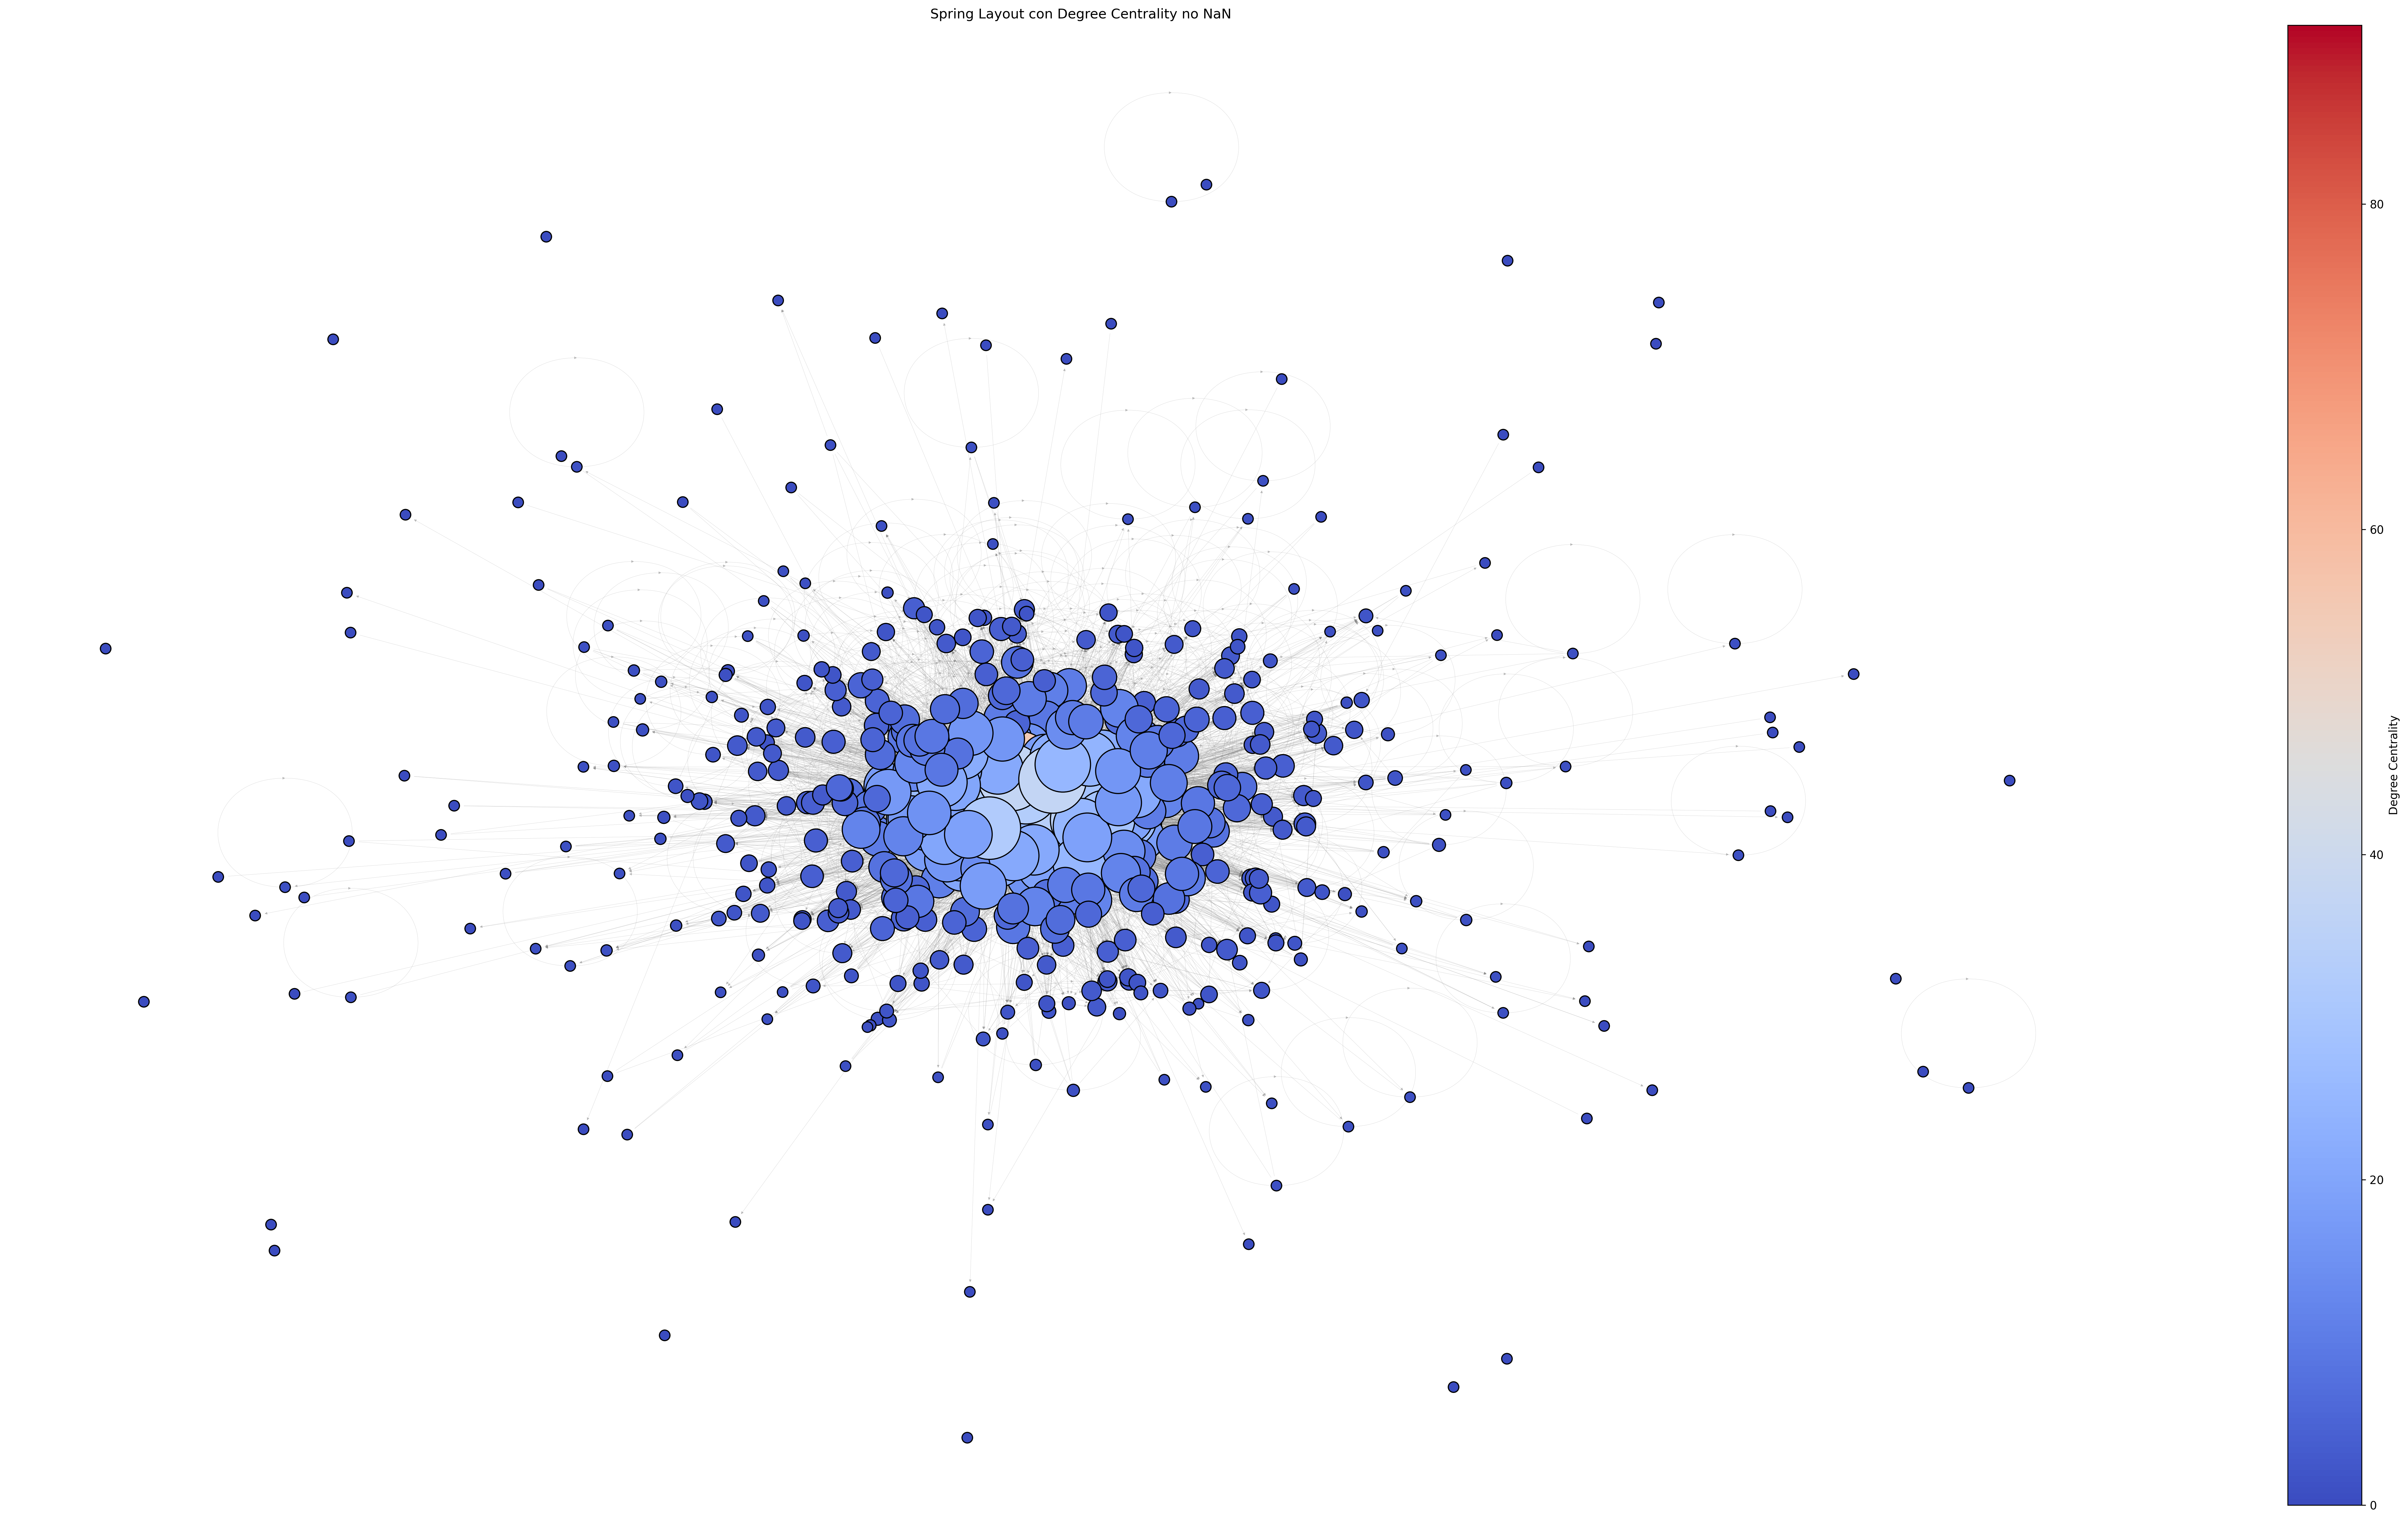

In [88]:
metrics = reload(metrics)
graphing = reload(graphing)


name = "spring-DEGREE-no-nan"
label = "Degree Centrality"
title = "Spring Layout con Degree Centrality nnetworkx parallel edges collpase weightnetworkx parallel edges collpase weightN"
pos = graphing.GLAYOUTS.spring(G, k=0.8, iterations=20, method="auto")
# k controls the distance between the nodes and varies between 0 and 1
# iterations is the number of times simulated annealing is run
# default k=0.1 and iterations=50
data = graphing.gen_graph_data(G, pos, M.degree_cent, log_distances=True)
data["node_colors"] = [round(i * 100) for i in M.degree_cent.values()]
graphing.plot_graph(data,
                    label=label,
                    title=title,
                    figsize=graphing.FigSize.XE16_9,
                    save_path=f"{SESSION_PATH}/{name}",
                    show_labels=False
                   )

In [86]:
metrics = reload(metrics)
graphing = reload(graphing)


name = "spring-CLOSENESS-no-nan"
label = "Closeness Centrality"
title = "Spring Layout con Closeness Centrality no NaN"
pos = graphing.GLAYOUTS.spring(G, k=0.8, iterations=20, method="auto")
# k controls the distance between the nodes and varies between 0 and 1
# iterations is the number of times simulated annealing is run
# default k=0.1 and iterations=50
data = graphing.gen_graph_data(G, pos, M.closeness_cent, log_distances=True)
data["node_colors"] = [round(i * 100) for i in M.closeness_cent.values()]
graphing.plot_graph(data,
                    label=label,
                    title=title,
                    figsize=graphing.FigSize.XE16_9,
                    save_path=f"{SESSION_PATH}/{name}",
                    show_labels=False
                   )

0.12526959929389705
FigSize.M16_9


Traceback (most recent call last):
  File "/home/began/.local/virtualenvs/data/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_48697/3256558200.py", line 14, in <module>
    graphing.plot_graph(data,
    ~~~~~~~~~~~~~~~~~~~^^^^^^
                        label=label,
                        ^^^^^^^^^^^^
    ...<2 lines>...
                        show_labels=False
                        ^^^^^^^^^^^^^^^^^
                       )
                       ^
  File "/home/began/srcs/data_science/ML4Cyber/Progetto_SNA/utils/graphing.py", line 198, in plot_graph
    nx.draw_networkx_edges(
    ~~~~~~~~~~~~~~~~~~~~~~^
        data["G"],
        ^^^^^^^^^^
    ...<4 lines>...
        width=0.15,
        ^^^^^^^^^^^
    )
    ^
  File "/home/began/.local/virtualenvs/data/lib/python3.13/site-packages/networkx/drawing/nx_pylab.py"

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f28ee327100> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
metrics = reload(metrics)
graphing = reload(graphing)


name = "spring-BETWEENNESS-no-nan"
label = "Betweenness Centrality"
title = "Spring Layout con Betweenness Centrality no NaN"
pos = graphing.GLAYOUTS.spring(G, k=0.8, iterations=20, method="auto")
# k controls the distance between the nodes and varies between 0 and 1
# iterations is the number of times simulated annealing is run
# default k=0.1 and iterations=50
data = graphing.gen_graph_data(G, pos, M.betweenness_cent, log_distances=True)
data["node_colors"] = [round(i * 100) for i in M.betweenness_cent.values()]
graphing.plot_graph(data,
                    label=label,
                    title=title,
                    figsize=graphing.FigSize.XE16_9,
                    save_path=f"{SESSION_PATH}/{name}",
                    show_labels=False
                   )

In [ ]:
metrics = reload(metrics)
graphing = reload(graphing)


name = "spring-EIGENVECTOR-no-nan"
label = "Eigenvector Centrality"
title = "Spring Layout con Eigenvector Centrality no NaN"
pos = graphing.GLAYOUTS.spring(G, k=0.8, iterations=20, method="auto")
# k controls the distance between the nodes and varies between 0 and 1
# iterations is the number of times simulated annealing is run
# default k=0.1 and iterations=50
data = graphing.gen_graph_data(G, pos, M.eigenvector_cent, log_distances=True)
data["node_colors"] = [round(i * 100) for i in M.eigenvector_cent.values()]
graphing.plot_graph(data,
                    label=label,
                    title=title,
                    figsize=graphing.FigSize.XE16_9,
                    save_path=f"{SESSION_PATH}/{name}",
                    show_labels=False
                   )

# Metriche

Qua calcoliamo:
- closeness centrality
- degree centrality
- betweenness centrality
- eigenvector centrality

### Definizione funzioni

In [ ]:
# per testing e sviluppo delle librerie, rilanciare questo blocco ogni volta che viene
# aggiornata una libreria

# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0


metrics = reload(metrics)

### Calcolo Metriche

In [5]:
g = nx.DiGraph()
graphing.add_edges(g, citations_uni)

In [ ]:
gm = metrics.GraphMetrics(g, SESSION_PATH)
gm.calc_metrics()

In [ ]:
gm.plot_distribution(gm.degree_cent.values(), "Degree Centrality Distribuition", 0.80)

In [ ]:
gm.plot_distribution(gm.closeness_cent.values(), "Closeness Centrality Distribuition", 0.80)

In [ ]:
gm.plot_distribution(gm.betweenness_cent.values(), "Betweenness Centrality Distribuition", 0.033)

In [ ]:
max(gm.betweenness_cent.values())

In [ ]:
max(gm.eigenvector_cent.values())

In [ ]:
gm.plot_distribution(gm.eigenvector_cent.values(), "Eigenvector Centrality Distribuition", 0.15)

In [ ]:
max(gm.indegree.values())

In [ ]:
gm.plot_distribution(gm.indegree.values(), "Indegree Distribuition", 0.65)

In [ ]:
max(gm.outdegree.values())

In [ ]:
gm.plot_distribution(gm.outdegree.values(), "Outdegree Distribuition", 0.85)

In [ ]:
max(gm.clustering_coef.values())

In [ ]:
gm.plot_distribution(gm.clustering_coef.values(), "Clustering Distribution", 1)

In [ ]:
max(gm.pagerank.values())

In [ ]:
gm.plot_distribution(gm.pagerank.values(), "Pagerank Distribution", 0.02)

In [ ]:
max(gm.k_core.values())

In [ ]:
gm.plot_distribution(gm.k_core.values(), "K-Core Distribution", 97)

In [ ]:
gm.density

In [ ]:
networkx parallel edges collpase weightgm.reciprocity

In [ ]:
gm.diameter

## Triadi

il seguente blocco di codice è stato usato per tentare di salvare su file tutte le triadi (nodi ed archi) su file, in quanto la ram non riusciva a tenerle tutte.
Bene, neanche su file ha senso farlo perchè il totale era arrivato a più di 5GB e stava continuando ad andare. Ho dovuto fermare.

In [ ]:
def write_cache(nodes: list, edges: list):
    with open(f"{SESSION_PATH}/triads-nodes.txt", 'a') as f:
        for node_list in nodes:
            f.write(','.join(map(str, node_list)) + '\n')
    with open(f"{SESSION_PATH}/triads-edges.txt", 'a') as f:
        for edge_list in edges:
            f.write(','.join(map(str, edge_list)) + '\n')

tris_nodes = []
tris_edges = []
for i, tri in enumerate(nx.all_triads(g)):
    if i % 5000 == 0 and i > 0:
        write_cache(tris_nodes, tris_edges)
        tris_nodes = []
        tris_edges = []
    tris_nodes.append(list(tri.nodes))
    tris_edges.append(list(tri.edges))

if tris_nodes:
    write_cache(tris_nodes, tris_edges)

In [6]:
# intanto, rimuoviamo il nodo NaN, in questa analisi è fuorviante
G = g.copy()
nan_nodes = []
for node in G.nodes(): 
    if not isinstance(node, str) and math.isnan(node):
        nan_nodes.append(node)
G.remove_nodes_from(nan_nodes)

In [ ]:
print(len(g.nodes) - len(G.nodes)) # nel grafo originale c'è solo un nodo nan
print(len(g.edges) - len(G.edges)) # al quale vi andavano 862 archi (solo?)
# questo tuttavia porta ad un altissimo degree

In [ ]:
nx.triadic_census(G)

In [ ]:
nx.triadic_census(g)

In [ ]:
g.in_edges(nan_nodes[0])

In [ ]:
g.out_edges(nan_nodes[0]) 

In [ ]:
# test per vedere differenza dello spring con e senza nan
M = metrics.GraphMetrics(G, SESSION_PATH)
M.calc_metrics()

In [ ]:
M.plot_distribution(M.degree_cent.values(), "Degree Centrality Distribuition - No NaN", 0.80)

In [ ]:
# Source - https://stackoverflow.com/a/437591
# Posted by cdleary, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-21, License - CC BY-SA 4.0
metrics = reload(metrics)
graphing = reload(graphing)

name = "spring-DEGREE-no-nan"
label = "Degree Centrality senza NaN"
title = "Spring Layout con Degree Centrality - Grafo senza NaN"

lay = graphing.GLAYOUTS.spring 
pos = lay(G, weight="w", method="energy")
data = graphing.gen_graph_data(G, pos, M.degree_cent)
data["node_colors"] = [round(i*100) for i in M.degree_cent.values()]
graphing.plot_graph(data, label=label, title=title, figsize=graphing.FigSize.XXXL16_9, save_path=f"{SESSION_PATH}/{name}", show_labels=False)

In [ ]:
for i, tri in enumerate(nx.all_triads(g))

## Clique

per poter usare enumerate_all_cliques e find_cliques, in networkx, dobbiamo trasformare il grafo da diretto ad indiretto

inoltre ci serve il grafo pesato

In [35]:
graphing = reload(graphing)
H = nx.Graph()
graphing.add_edges_with_weight(H, citations_uni)

In [37]:
for n in H.nodes:
    H.nodes[n]["weight"] = H.degree(n)

In [40]:
for n in H.nodes:
    H.nodes[n]["weight"] = 1

In [41]:
maximal = 0
allc = 0

# for i in nx.enumerate_all_cliques(H):
#    allc += 1
# TROPPE -> riempe la ram

for i in nx.find_cliques(H):
    maximal += 1
    
maxn, maxc = nx.max_weight_clique(H)


print(f"clique trovate {allc}")
print(f"clique massimali trovate {maximal}")
print(f"clique massima: {maxc}")

clique trovate 0
clique massimali trovate 120854
clique massima: 45


In [20]:
nx.node_clique_number(H)

defaultdict(int,
            {'Neuroscience Institute': 18,
             'University of Lodz': 12,
             'Abdus Salam international centre for theoretical physics': 44,
             'Istituto Nazionale di Fisica Nucleare, Sezione di Bologna': 44,
             'New York Sea Grant': 44,
             'Universidad Autónoma de Zacatecas': 5,
             'Universidad Nacional Autónoma de México': 27,
             'University of Cyprus': 5,
             'Harvard University': 44,
             'Aristotle University of Thessaloniki': 19,
             'London South Bank University': 44,
             'Institute of Biology and Immunology of Reproduction': 2,
             'Massachusetts Institute of Technology': 44,
             'Princeton University': 44,
             'University of Cambridge': 44,
             'Stanford University': 44,
             'Chaudhary Charan Singh Haryana Agricultural University': 44,
             'Von Karman Institute for Fluid Dynamics': 44,
             'Univer

In [21]:
graphing.edge_collapse()
nx.max_weight_clique(H)

KeyError: "Node 'The University of Texas at Austin' does not have the requested weight field."